In [1]:
from autoenkoop import *
import torch
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import os
import pydmd
from tqdm import tqdm
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt

DEVICE = "cuda"

In [2]:
data_path = os.path.join("..", "data", "T1492_x1151_y1_z127_c2.npz")
center_dataset = True
train_test_split = 0.7
train_data, test_data, temp_mean = load_and_prepare_data(data_path, center_dataset, train_test_split)

In [3]:
full_data = np.concatenate((train_data, test_data), axis=0)

original_data = full_data + temp_mean
temp_mean_error = np.mean((full_data - temp_mean)**2, axis=(1,2,3))
(vx_min, vx_max), (vz_min, vz_max) = get_min_max(original_data)
vx_absmax = max(abs(vx_min), abs(vx_max))*0.02
vz_absmax = max(abs(vz_min), abs(vz_max))*0.02
norm_x = Normalize(vmin=-vx_absmax, vmax=+vx_absmax)
norm_z = Normalize(vmin=-vz_absmax, vmax=+vz_absmax)

In [4]:
full_data.shape

(1493, 1151, 127, 2)

In [5]:
PREDICTION_WINDOW = 100
window_offset_data = full_data[:-PREDICTION_WINDOW]

dataset_full = SimpleDataset(window_offset_data)

loader_full = DataLoader(dataset_full, batch_size=1, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

dataset_train = SimpleDataset(train_data)
loader_train = DataLoader(dataset_train, batch_size=4, shuffle=False)

full_data = np.moveaxis(full_data, -1, 1)

In [6]:
train_test_cutoff = int(full_data.shape[0]*0.7)
print(train_test_cutoff)

1045


In [7]:
def calculate_koopman(model, loader):
    Z = []
    with torch.no_grad():
        for x_t in loader:
            x_t = x_t.to(DEVICE)
            #encoded current state
            z_t = model.encoder(x_t) 
            Z.append(z_t.cpu().numpy())
    Z_all = np.vstack(Z).T
    dmd = pydmd.DMD(-1, forward_backward=False)
    dmd.fit(Z_all)
    K_star = (dmd.modes @ np.diag(dmd.eigs) @ np.linalg.pinv(dmd.modes)).real
    return K_star

L128_dmd_none_batch_batch_nobias_wlin1
False


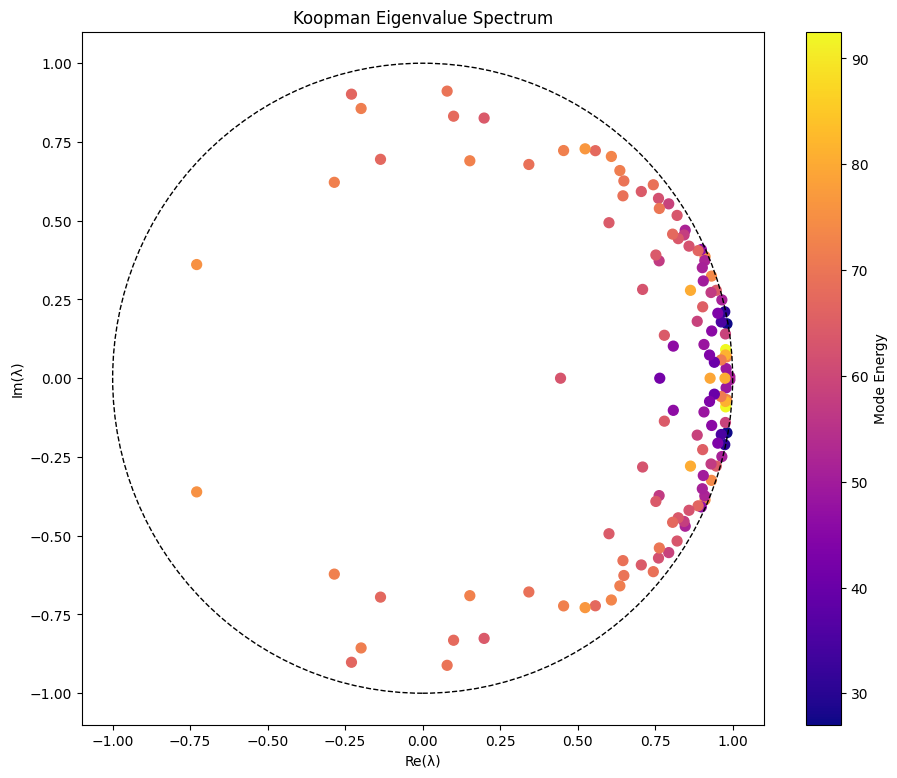

128
L128_dmd_none_batch_none_nobias_wlin1
False


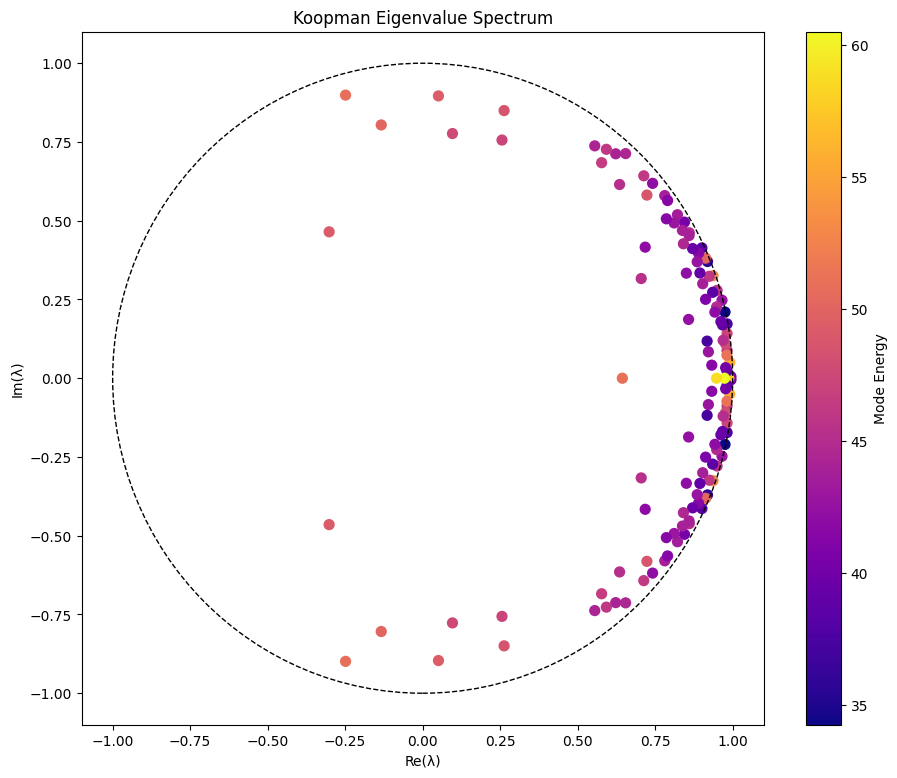

128
L128_train_none_batch_none_bias_wlin1
False


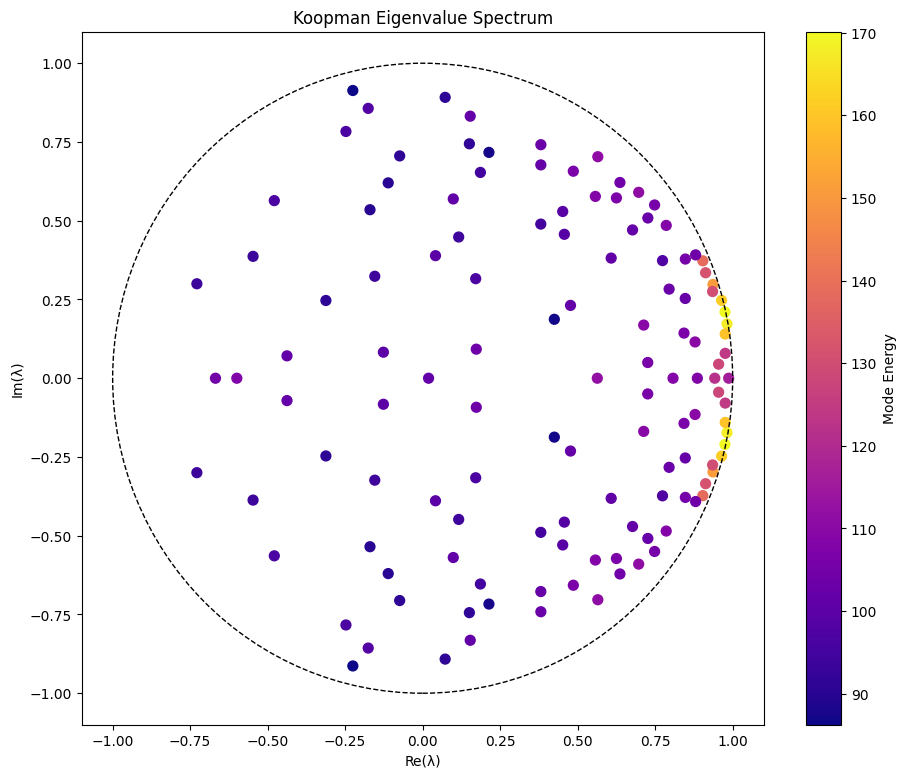

128
L128_dmd_none_none_none_nobias_wlin1_smalllr
False


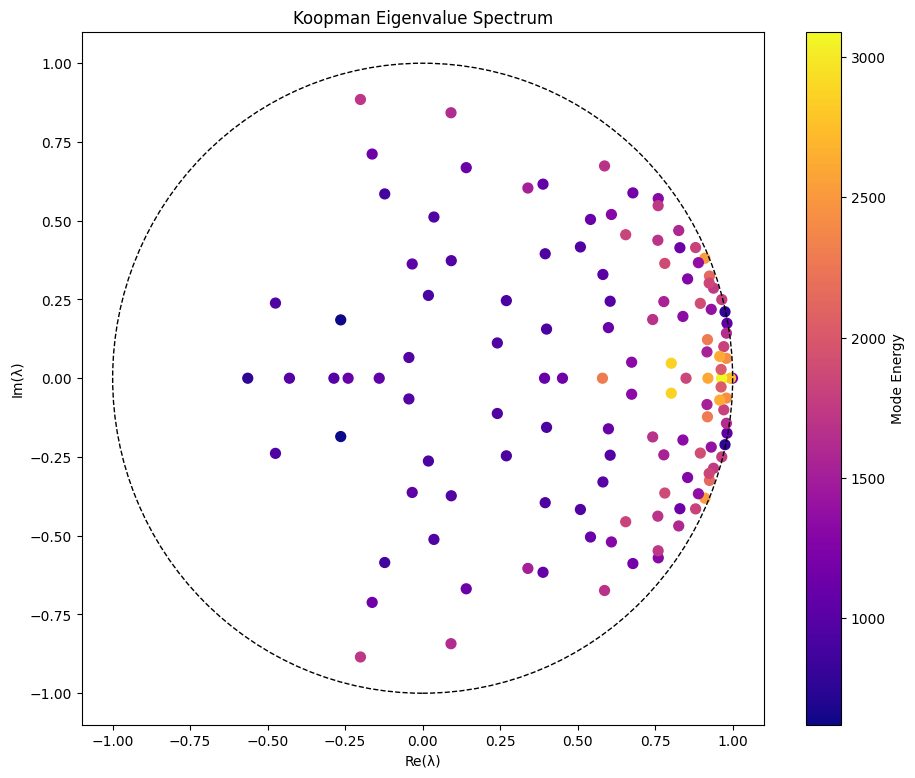

128
L128_dmd_none_batch_none_nobias_wlin1_relerr
False


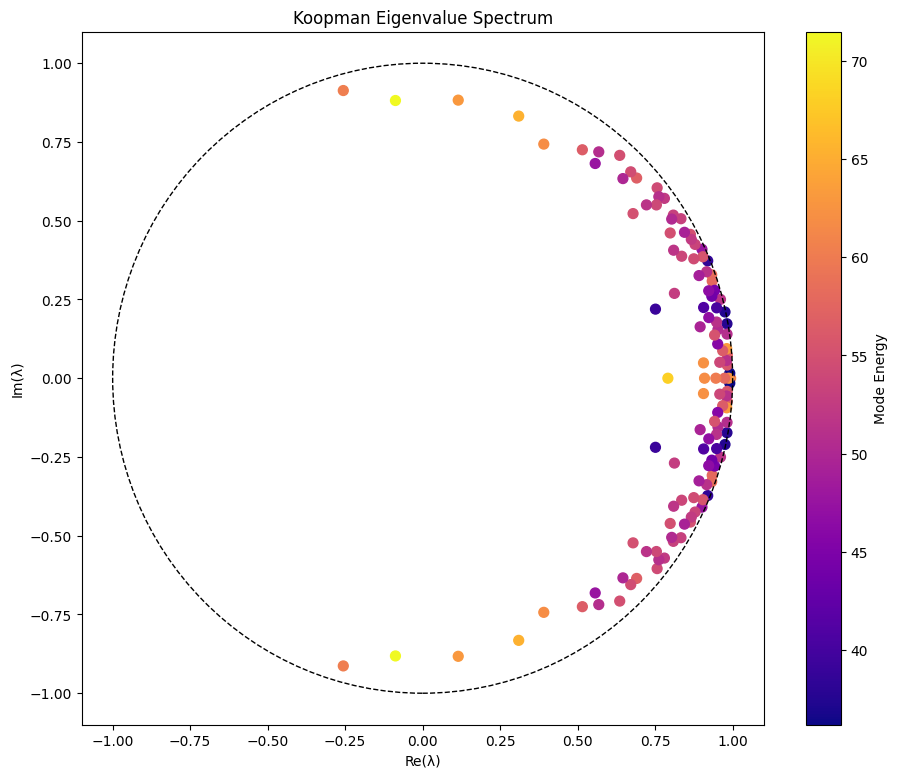

128


100%|██████████| 1393/1393 [03:02<00:00,  7.65it/s]


In [165]:
results_path = os.path.join("..", "results")
run_name_list = [
    #"L128_train_batch_nobias_wlin1",
    #"L128_train_layer_nobias_wlin1",
    #"L128_dmd_batch_norm_nobias_wlin0.1",
    #"L128_dmd_batch_norm_nobias_wlin1",
    "L128_dmd_none_batch_batch_nobias_wlin1",
    "L128_dmd_none_batch_none_nobias_wlin1",
    #"L128_dmd_layer_layer_nobias_wlin1",
    #"L128_dmd_layer_rms_nobias_wlin1",
    #"L128_train_layer_rms_nobias_wlin1",
    #"L128_dmd_none_layer_batch_nobias_wlin1",
    #"L128_dmd_none_batch_none_nobias_wlin1",
    #"L128_train_none_batch_none_nobias_wlin1",
    "L128_train_none_batch_none_bias_wlin1",
    #"L128_dmd_none_batch_rms_nobias_wlin1",
    #"L128_dmd_none_layer_none_nobias_wlin1",
    #"L128_dmd_weightstd_standard_none_nobias_wlin1",
    #"L128_dmd_none_none_none_nobias_wlin1",
    "L128_dmd_none_none_none_nobias_wlin1_smalllr",
    "L128_dmd_none_batch_none_nobias_wlin1_relerr",
    #"L128_dmd_none_none_none_nobias_wlin1_highlr",
    #"L128_dmd_weightstd_norm_none_nobias_wlin1_highlr"
    #"L128_dmd_weightstd_none_none_nobias_wlin1_AdamW",
    #"L128_dmd_weightstd_none_none_nobias_wlin2",
    #"L128_dmd_weightstd_none_none_nobias_wlin0.1",
    #"L128_dmd_weightstd_none_none_nobias_wlin0.01",
    #"L128_train_none_batch_none_nobias_wlin1",
    #"L128_train_none_batch_none_bias_wlin1",
    #"L128_train_batch_nonorm_nobias_wlin1",
    #"L16_train_batch_nonorm_nobias_wlin1",
    #"L16_dmd_batch_norm_nobias_wlin1",
    #"L128_dmd_batch_nonorm_nobias_wlin1",
    #"L128_dmd_batch_norm_nobias_wlin10",
    #"L128_dmd_batch_nobias_wlin100",
    #"L128_dmd_batch_nobias_wlin1000",
    #"L128_dmd_layer_nobias_wlin1",
    #"L128_dmd_layer_nobias_wlin10",
    #"L128_dmd_layer_nobias_wlin100",
    #"L128_dmd_layer_nobias_wlin1000",
    #"L128_train_batch_bias_wlin1",
    #"L128_train_layer_bias_wlin1",
    #"L128_dmd_batch_bias_wlin1",
    #"L128_dmd_layer_bias_wlin1",
]

CALCULATE_DMD_FOR_TRAINED = True
REDUCE_THRESHOLD = 1.0#0.0225

prediction_mse_windows = []

for run_name in run_name_list:
    print(run_name)
    run_path = os.path.join(results_path, "kae_experiments", run_name)
    
    hyperparam = run_name.split('_')
    
    LATENT_DIM = int(hyperparam[0][1:])
    koopman_type = hyperparam[1]
    weight_std = hyperparam[2] == "weightstd"
    print(weight_std)
    norm_type = hyperparam[3]
    norm_latent = hyperparam[4]
    use_bias = hyperparam[5] == "bias"

    model = ConvAutoencoder(latent_dim=LATENT_DIM, weight_standard=weight_std, bias_terms=use_bias, norm_type=norm_type, norm_latent=norm_latent).to(DEVICE)
    
    model.load_state_dict(torch.load(os.path.join(run_path, "model.pt"), map_location=DEVICE))
    model.eval()

    if koopman_type == "dmd" or CALCULATE_DMD_FOR_TRAINED:
        koopman_type = "dmd"
        K = torch.tensor(calculate_koopman(model, loader_train), device=DEVICE, requires_grad=False)
        #lin_weights = torch.tensor(K, device=DEVICE, requires_grad=True)
        #linfunction = lambda z_t : torch.nn.functional.linear(z_t, K)
    else:
        #linfunction = lambda z_t : model.linear_dynamics(z_t)
        with torch.no_grad():
            K = model.linear_dynamics.weight.detach()#.cpu().numpy()
    
    K_numpy = K.cpu().numpy()
    eigvalues, eigvectors = get_sorted_eigen(K_numpy)
    eigenergies = eigenvalue_energies(model, eigvectors, DEVICE)
    plot_eigenvalue_spectrum(eigvalues, eigvectors, eigenergies)

    predictor, eigenvalues_reduced = get_multi_step_predictor(K, REDUCE_THRESHOLD)
    num_eigenvalues = eigenvalues_reduced.cpu().numpy().shape[0]
    print(num_eigenvalues)
    #break
    
    prediction_window_path = os.path.join(run_path,"pred_window"+str(PREDICTION_WINDOW)+"_mse_"+koopman_type+"_"+str(num_eigenvalues)+".npy")
    if os.path.exists(prediction_window_path):
        prediction_mse = np.load(prediction_window_path)
    else:
        prediction_mse = np.zeros((window_offset_data.shape[0], PREDICTION_WINDOW+1))
        with torch.no_grad():
            for j, x_t in tqdm(enumerate(loader_full), total=len(dataset_full)):
                x_t = x_t.to(DEVICE)
                z_t = model.encoder(x_t).squeeze(0)
                z_trajectory = predictor(z_t, PREDICTION_WINDOW)
                X_prediction = model.decoder(z_trajectory).cpu().numpy()
                #X_prediction = predict_window(x_t, model, linfunction, PREDICTION_WINDOW)
                mse_window = np.mean((full_data[j:j+PREDICTION_WINDOW+1] - X_prediction)**2, axis=(1,2,3))
                prediction_mse[j] = mse_window
        np.save(prediction_window_path[:-4], prediction_mse)
    prediction_mse_windows.append(prediction_mse)
            
    
    
    #
    #break

In [102]:
steady_tolerance = 0.01

stable_values, stable_vectors, stable_energies = get_stable_modes(eigvalues, eigvectors, eigenergies, steady_tolerance, False)

6 stable mode explain: 7.25% of the energy


In [ ]:
mode_values, mode_vectors, mode_energies = filter_pos_imag(stable_values, stable_vectors, stable_energies)
stable_structures = calculate_eigenmode_structures(mode_vectors, model, device=DEVICE)
for i, structure in enumerate(stable_structures):
    print(mode_values[i].item(),"\t", np.abs(mode_values[i].item()))
    print(mode_energies[i])
    vx = structure[0,:]
    vz = structure[1,:]
    plot_vx_vz(vx, vz, norm_x, norm_z)

In [ ]:
x_t = dataset_full[1147]
x_t = x_t.to(DEVICE).unsqueeze(0)
X_prediction = predict_window(x_t, model, linfunction, prediction_window)

In [ ]:
#example_index = 0
#
#vx = original_data[example_index, :, :, 0]
#vz = original_data[example_index, :, :, 1]
#
#plot_vx_vz(vx, vz, norm_x, norm_z)
#animate_trajectory(X_prediction+np.moveaxis(temp_mean, -1, 0), "prev_index_mode", norm_x, norm_z)

In [166]:
global_mse_list = []

for i, windowed_mse in enumerate(prediction_mse_windows):
    #if run_name_list[i] != "L128_e300_lamlin10_train":
    global_mse_list.append(np.mean(windowed_mse, 0))

In [167]:
train_mean_mse = []
test_mean_mse = []

for i, windowed_mse in enumerate(prediction_mse_windows):
    #if run_name_list[i] != "L128_e300_lamlin10_train":
    train_mean_mse.append(np.mean(windowed_mse[:train_test_cutoff], 0))
    test_mean_mse.append(np.mean(windowed_mse[train_test_cutoff:], 0))

In [168]:
train_mean_mse[-1]

array([0.00683484, 0.00708352, 0.00778245, 0.00924971, 0.01139237,
       0.01404343, 0.01684889, 0.01960148, 0.02228031, 0.02484195,
       0.02735227, 0.0297854 , 0.03208991, 0.03426894, 0.03634145,
       0.0383394 , 0.04024894, 0.04212795, 0.0440343 , 0.04593118,
       0.04779796, 0.04968917, 0.05162075, 0.05357425, 0.05556408,
       0.05760875, 0.0596831 , 0.06174976, 0.06380226, 0.06585803,
       0.06791328, 0.06997426, 0.07201013, 0.07402658, 0.07607074,
       0.0780723 , 0.08004111, 0.08198001, 0.0838683 , 0.08572447,
       0.08753585, 0.08930013, 0.09102119, 0.09269771, 0.09434898,
       0.0959857 , 0.09757418, 0.09911497, 0.10059125, 0.10203136,
       0.10345524, 0.10486099, 0.10622082, 0.10751357, 0.1087966 ,
       0.11009587, 0.11136842, 0.11261302, 0.11385599, 0.11510052,
       0.11637197, 0.1176572 , 0.11895461, 0.12025166, 0.12155124,
       0.12284233, 0.12411177, 0.12531413, 0.12644058, 0.127509  ,
       0.12851769, 0.1294758 , 0.13043191, 0.1313717 , 0.13228

In [169]:
test_mean_mse[-1]

array([0.06306329, 0.0660035 , 0.07190418, 0.07775395, 0.08233387,
       0.0861839 , 0.08959309, 0.09247133, 0.0949125 , 0.09696089,
       0.09900788, 0.10089017, 0.10260778, 0.10429322, 0.10601797,
       0.10768246, 0.10917986, 0.11051682, 0.11211839, 0.11393347,
       0.11561116, 0.11729792, 0.11912706, 0.12086177, 0.12256691,
       0.12427494, 0.12593318, 0.12745157, 0.12871127, 0.12985058,
       0.13105244, 0.13222789, 0.13349467, 0.13481585, 0.13604073,
       0.13733889, 0.13861005, 0.1397751 , 0.14105965, 0.14248402,
       0.14378594, 0.14506682, 0.14631166, 0.14741967, 0.1485282 ,
       0.14983021, 0.15116487, 0.15237886, 0.1533565 , 0.15428076,
       0.15523112, 0.15607044, 0.15688174, 0.15768482, 0.15833778,
       0.15882872, 0.1592668 , 0.15975019, 0.16037714, 0.1610687 ,
       0.16172224, 0.16235512, 0.16291285, 0.16340683, 0.16377083,
       0.16400408, 0.16419037, 0.16440357, 0.16470492, 0.16504852,
       0.1652848 , 0.16540061, 0.16547481, 0.16556313, 0.16568

In [170]:
mean_mse_list = []

for i, windowed_mse in enumerate(prediction_mse_windows):
    #if run_name_list[i] != "L128_e300_lamlin10_train":
    mean_mse_list.append(np.mean(windowed_mse, 1))

In [171]:
train_test_name_list = [name+" TRAIN" for name in run_name_list]+[name+" TEST" for name in run_name_list]

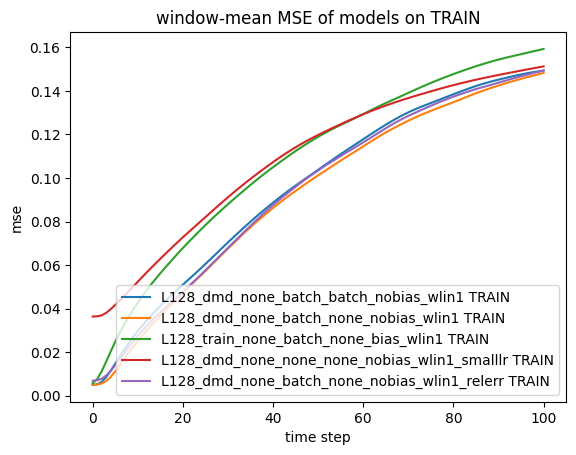

In [172]:
plot_evolution(train_mean_mse, [name+" TRAIN" for name in run_name_list], "window-mean MSE of models on TRAIN", "time step", "mse")
plt.yscale("linear")

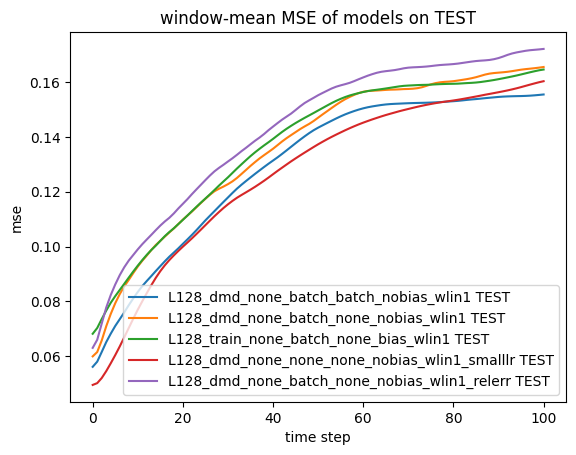

In [173]:
plot_evolution(test_mean_mse, [name+" TEST" for name in run_name_list], "window-mean MSE of models on TEST", "time step", "mse")
plt.yscale("linear")

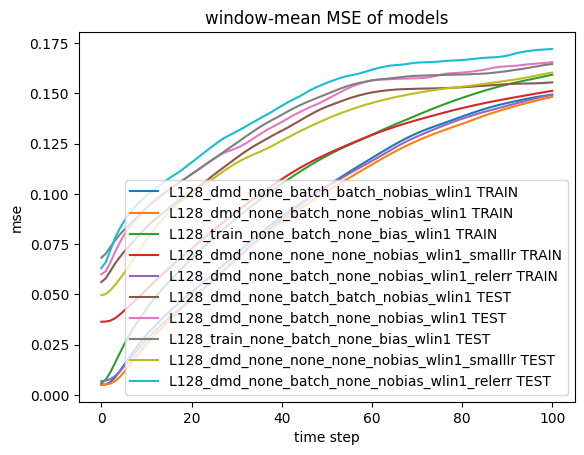

In [174]:
plot_evolution(train_mean_mse + test_mean_mse, train_test_name_list, "window-mean MSE of models", "time step", "mse")
plt.yscale("linear")

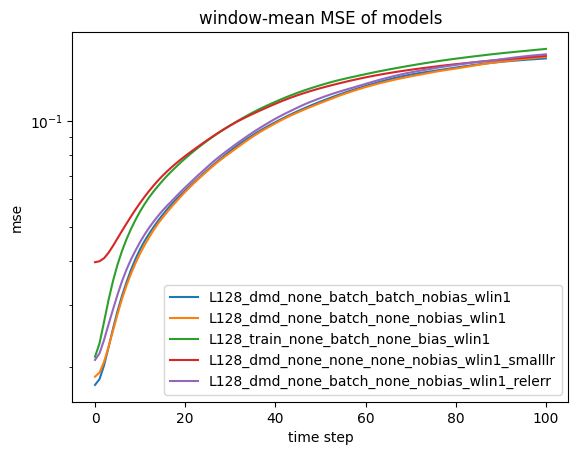

In [175]:
plot_evolution(global_mse_list, run_name_list, "window-mean MSE of models", "time step", "mse")

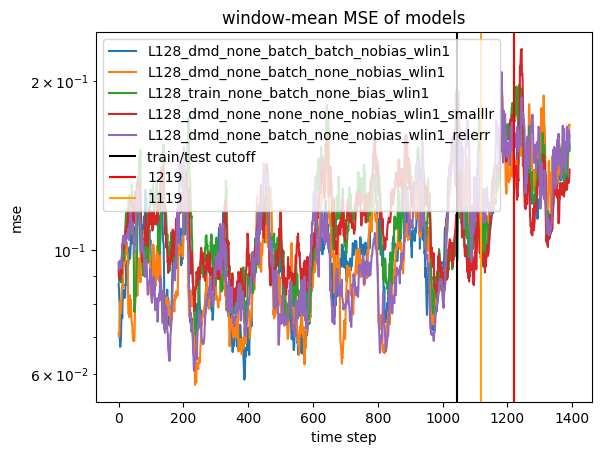

In [176]:
plot_evolution(mean_mse_list, run_name_list, "window-mean MSE of models", "time step", "mse")
#plt.yscale("linear")
plt.vlines(train_test_cutoff, 0.05, 0.5, colors=["black"], label="train/test cutoff")
plt.vlines(1219, 0.05, 0.5, colors=["red"], label="1219")
plt.vlines(1119, 0.05, 0.5, colors=["orange"], label="1119")
plt.legend()

In [115]:
np.argmax(mean_mse_list[2])

IndexError: list index out of range

In [ ]:
plot_evolution(mean_mse_list+[temp_mean_error[:1393]], run_name_list+["temp_mean_error"], "mean-window MSE of models", "time step", "mse")
plt.yscale("linear")
#plt.vlines(train_test_cutoff, 0, 2, colors=["black"])

In [ ]:
mean_mse_list[0][1147]

In [ ]:
np.argmax(mean_mse_list[0])